In [1]:
pip install qiskit

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
## Imports
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
import matplotlib.pyplot as plt
import copy
import random
from joblib import Parallel, delayed
import time
import math
from numpy import pi

🌱 Seeds configurées: 29
🎯 Circuit Cible:


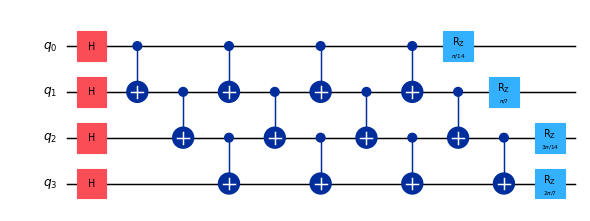

🚀 Démarrage de l'optimisation multi-objectifs...
Paramètres: 4 qubits, 12 gènes, 100 individus, 200 générations

Génération 1/200
Front de Pareto: 6 solutions
Fidélité: 0.1088 ± 0.1247
Profondeur: 4.17 ± 0.69
Coût: 14.17 ± 1.57

Génération 2/200
Front de Pareto: 3 solutions
Fidélité: 0.2488 ± 0.0613
Profondeur: 4.00 ± 0.82
Coût: 13.33 ± 1.25

Génération 3/200
Front de Pareto: 6 solutions
Fidélité: 0.1778 ± 0.1225
Profondeur: 3.83 ± 0.69
Coût: 12.50 ± 1.38

Génération 4/200
Front de Pareto: 7 solutions
Fidélité: 0.1789 ± 0.1107
Profondeur: 3.86 ± 0.83
Coût: 12.57 ± 1.40

Génération 5/200
Front de Pareto: 10 solutions
Fidélité: 0.1651 ± 0.1280
Profondeur: 3.70 ± 0.46
Coût: 12.20 ± 1.47

Génération 6/200
Front de Pareto: 10 solutions
Fidélité: 0.2039 ± 0.1735
Profondeur: 3.60 ± 0.49
Coût: 12.00 ± 1.48

Génération 7/200
Front de Pareto: 10 solutions
Fidélité: 0.2362 ± 0.1477
Profondeur: 3.80 ± 0.60
Coût: 11.90 ± 1.58

Génération 8/200
Front de Pareto: 7 solutions
Fidélité: 0.3578 ± 0.1364


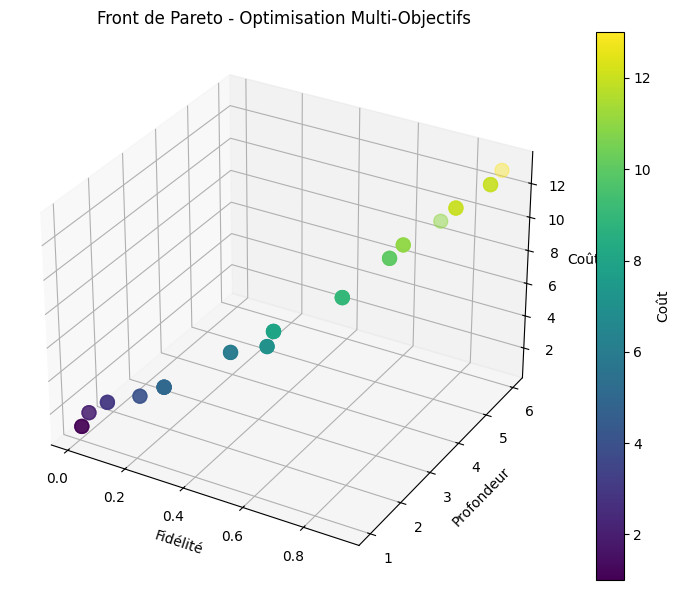

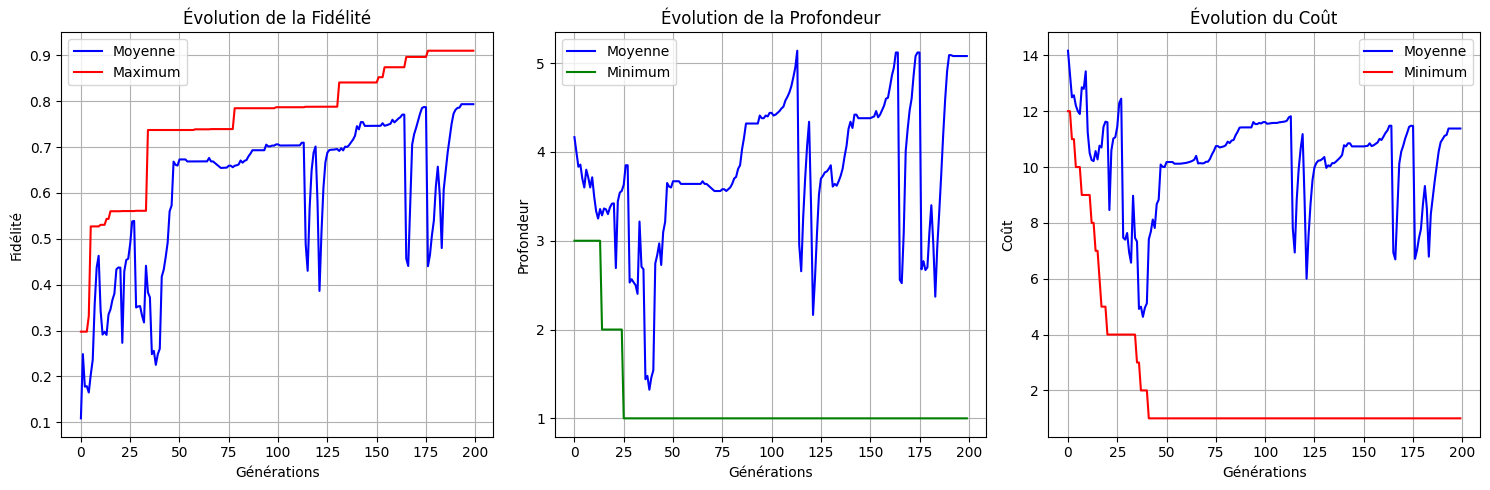


🏆 Meilleur circuit (fidélité):
Fidélité: 0.9130
Profondeur: 6
Coût: 13
Circuit Optimisé : 


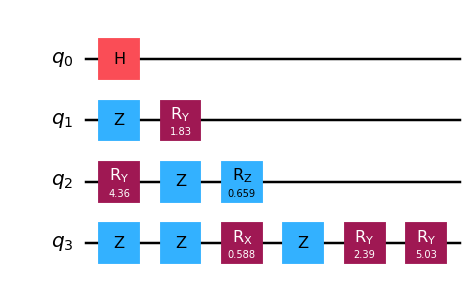

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from joblib import Parallel, delayed
import copy
from mpl_toolkits.mplot3d import Axes3D



# -------------------- Configuration des seeds --------------------
# utiliser seed pour assurer la génération de même suite de nombres aléatoires
def set_random_seeds(seed=42):
    """Configure toutes les graines aléatoires pour la reproductibilité."""
    np.random.seed(seed)
    random.seed(seed)
    # Pour matplotlib (si nécessaire pour les couleurs aléatoires)
    plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.Set1.colors)

    print(f"🌱 Seeds configurées: {seed}")

# -------------------- Coûts des portes --------------------
GATE_COSTS = {
    'NOT': 1,
    'Phase': 1,
    'H': 2,      # Hadamard
    'X': 1,
    'Y': 1,
    'Z': 1,
    'CX': 5,     # Équivalent à CNOT
    'SWAP': 11,
    'Peres': 12,
    'Toffoli': 13,
    'Fredkin': 19,
    'Miller': 24,
    'RX': 1,     # Rotation gates
    'RY': 1,
    'RZ': 1
}

# -------------------- Classe pour l'individu multi-objectifs --------------------
class MultiObjectiveIndividual:
    def __init__(self, chromosome, fitness_values=None):
        self.chromosome = chromosome
        self.fitness_values = fitness_values  # [fidelity, -depth, -cost]
        self.rank = None
        self.crowding_distance = 0
        self.dominated_by = []
        self.dominates = []

    # Implémentation mécanisme de dominance
    def dominates_other(self, other):
        """Vérifie si cet individu domine un autre (tous objectifs >= et au moins un >)"""
        if self.fitness_values is None or other.fitness_values is None:
            return False

        better_in_all = all(self.fitness_values[i] >= other.fitness_values[i] for i in range(len(self.fitness_values)))
        better_in_at_least_one = any(self.fitness_values[i] > other.fitness_values[i] for i in range(len(self.fitness_values)))

        return better_in_all and better_in_at_least_one

# -------------------- Génération des circuits --------------------

# génération de gènes sous forme gène = [qubit_cible, porte, qubit_control, angle]
def generate_gene(num_qubits):
    """Génère un gène aléatoire représentant une porte quantique."""
    quantum_gates = {
        "H": {"control": False, "rotation": False},
        "X": {"control": False, "rotation": False},
        "Y": {"control": False, "rotation": False},
        "Z": {"control": False, "rotation": False},
        "CX": {"control": True, "rotation": False},
        "RX": {"control": False, "rotation": True},
        "RY": {"control": False, "rotation": True},
        "RZ": {"control": False, "rotation": True}
    }

    target_qubit = np.random.randint(num_qubits)
    gate = np.random.choice(list(quantum_gates.keys()))
    control_qubit = None
    angle = None

    if quantum_gates[gate]["control"]:
        control_qubit = np.random.randint(num_qubits)
        while control_qubit == target_qubit:
            control_qubit = np.random.randint(num_qubits)

    if quantum_gates[gate]["rotation"]:
        angle = np.random.uniform(0, 2 * np.pi)

    return [target_qubit, gate, control_qubit, angle]

# génération de chromosome "suite de gènes"
def generate_chromosome(num_qubits, num_genes):
    """Génère un chromosome (séquence de gènes)."""
    return [generate_gene(num_qubits) for _ in range(num_genes)]

# génération de population
def generate_population(pop_size, num_qubits, num_genes):
    """Génère une population de chromosomes."""
    return [generate_chromosome(num_qubits, num_genes) for _ in range(pop_size)]

# traduction de chromosome à un circuit quantique
def create_quantum_circuit(chromosome, num_qubits):
    """Transforme un chromosome en circuit quantique Qiskit."""
    circuit = QuantumCircuit(num_qubits)

    for gene in chromosome:
        target, gate, control, angle = gene

        if gate in ["H", "X", "Y", "Z"]:
            getattr(circuit, gate.lower())(target)
        elif gate == "CX":
            circuit.cx(control, target)
        elif gate in ["RX", "RY", "RZ"]:
            getattr(circuit, gate.lower())(angle, target)

    return circuit

# -------------------- Fonctions d'évaluation multi-objectifs --------------------

# calculer la fidélité (formule de trace overlap)
def compute_fidelity(circuit, target_unitary):
    """Calcule la fidélité du circuit par rapport à l'unitaire cible."""
    candidate_unitary = Operator(circuit).data
    target_dagger = np.conj(target_unitary).T
    trace_value = np.trace(np.dot(candidate_unitary, target_dagger))
    num_qubits = circuit.num_qubits
    return np.abs(trace_value) / (2 ** num_qubits)

# calculer la profondeur de circuit
def compute_circuit_depth(circuit):
    """Calcule la profondeur du circuit."""
    return circuit.depth()

# calculer le cout de circuit
def compute_circuit_cost(chromosome):
    """Calcule le coût total du circuit basé sur les portes utilisées."""
    total_cost = 0
    for gene in chromosome:
        gate = gene[1]
        if gate in GATE_COSTS:
            total_cost += GATE_COSTS[gate]
        else:
            total_cost += 1  # Coût par défaut
    return total_cost


#retourner le triplet [fitness, depth, cost]
def evaluate_individual(chromosome, num_qubits, target_unitary):
    """Évalue un individu sur les trois objectifs."""
    circuit = create_quantum_circuit(chromosome, num_qubits)

    # Objectif 1: Fidélité (à maximiser)
    fidelity = compute_fidelity(circuit, target_unitary)

    # Objectif 2: Profondeur (à minimiser -> on prend le négatif)
    depth = compute_circuit_depth(circuit)

    # Objectif 3: Coût (à minimiser -> on prend le négatif)
    cost = compute_circuit_cost(chromosome)

    # Retourne [fidelity, -depth, -cost] pour maximiser tous les objectifs
    return [fidelity, -depth, -cost]

def parallel_evaluation(population, num_qubits, target_unitary):
    """Évaluation parallèle de la population."""
    return Parallel(n_jobs=-1)(
        delayed(evaluate_individual)(chromo, num_qubits, target_unitary)
        for chromo in population
    )

# -------------------- NSGA-II Implementation --------------------
def fast_non_dominated_sort(population):
    """Tri non-dominé (NSGA-II)."""
    fronts = [[]]

    for i, ind_i in enumerate(population):
        ind_i.dominated_by = []
        ind_i.dominates = []

        for j, ind_j in enumerate(population):
            if i != j:
                if ind_i.dominates_other(ind_j):
                    ind_i.dominates.append(j)
                elif ind_j.dominates_other(ind_i):
                    ind_i.dominated_by.append(j)

        if len(ind_i.dominated_by) == 0:
            ind_i.rank = 0
            fronts[0].append(i)

    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in population[p].dominates:
                population[q].dominated_by.remove(p)
                if len(population[q].dominated_by) == 0:
                    population[q].rank = i + 1
                    next_front.append(q)
        i += 1
        fronts.append(next_front)

    return fronts[:-1]  # Enlever le dernier front vide

def calculate_crowding_distance(population, front):
    """Calcule la distance de crowding pour un front donné."""
    if len(front) <= 2:
        for i in front:
            population[i].crowding_distance = float('inf')
        return

    # Initialiser les distances
    for i in front:
        population[i].crowding_distance = 0

    # Pour chaque objectif
    num_objectives = len(population[front[0]].fitness_values)
    for obj in range(num_objectives):
        # Trier par objectif
        front.sort(key=lambda x: population[x].fitness_values[obj])

        # Assigner distance infinie aux extrêmes
        population[front[0]].crowding_distance = float('inf')
        population[front[-1]].crowding_distance = float('inf')

        # Calculer pour les autres
        if len(front) > 2:
            obj_range = population[front[-1]].fitness_values[obj] - population[front[0]].fitness_values[obj]
            if obj_range > 0:
                for i in range(1, len(front) - 1):
                    distance = (population[front[i + 1]].fitness_values[obj] -
                              population[front[i - 1]].fitness_values[obj]) / obj_range
                    population[front[i]].crowding_distance += distance

def nsga2_selection(population, pop_size):
    """Sélection NSGA-II."""
    fronts = fast_non_dominated_sort(population)

    new_population = []
    for front in fronts:
        calculate_crowding_distance(population, front)

        if len(new_population) + len(front) <= pop_size:
            new_population.extend([population[i] for i in front])
        else:
            # Trier par distance de crowding décroissante
            front.sort(key=lambda x: population[x].crowding_distance, reverse=True)
            remaining = pop_size - len(new_population)
            new_population.extend([population[i] for i in front[:remaining]])
            break

    return new_population

# -------------------- Opérateurs génétiques --------------------
def crossover(parent1, parent2):
    """Croisement entre deux parents."""
    min_length = min(len(parent1), len(parent2))
    if min_length < 2:
        return parent1.copy(), parent2.copy()

    cut_point = np.random.randint(1, min_length)
    child1 = parent1[:cut_point] + parent2[cut_point:]
    child2 = parent2[:cut_point] + parent1[cut_point:]

    return child1, child2

def mutate(chromosome, num_qubits, mutation_rate=0.1):
    """Mutation d'un chromosome."""
    if np.random.rand() < mutation_rate:
        # Mutation de gène
        if len(chromosome) > 0:
            idx = np.random.randint(len(chromosome))
            chromosome[idx] = generate_gene(num_qubits)

    # Mutation structurelle
    if np.random.rand() < 0.1:
        if np.random.rand() < 0.5 and len(chromosome) > 1:
            # Supprimer un gène
            idx = np.random.randint(len(chromosome))
            del chromosome[idx]
        else:
            # Ajouter un gène
            new_gene = generate_gene(num_qubits)
            idx = np.random.randint(len(chromosome) + 1)
            chromosome.insert(idx, new_gene)

    return chromosome

def tournament_selection(population, tournament_size=3):
    """Sélection par tournoi pour le croisement."""
    tournament = np.random.choice(population, tournament_size, replace=False)

    # Choisir le meilleur selon le rang et la distance de crowding
    best = tournament[0]
    for individual in tournament[1:]:
        if (individual.rank < best.rank or
            (individual.rank == best.rank and individual.crowding_distance > best.crowding_distance)):
            best = individual

    return best

# -------------------- Algorithme génétique multi-objectifs --------------------
def multi_objective_genetic_algorithm(num_qubits, num_genes, pop_size, generations, target_unitary,
                                    mutation_rate=0.1, crossover_rate=0.9):
    """Algorithme génétique multi-objectifs principal."""

    # Initialiser la population
    chromosomes = generate_population(pop_size, num_qubits, num_genes)
    fitness_values = parallel_evaluation(chromosomes, num_qubits, target_unitary)

    population = [MultiObjectiveIndividual(chromo, fitness)
                  for chromo, fitness in zip(chromosomes, fitness_values)]

    # Historique des fronts de Pareto
    pareto_history = []

    for generation in range(generations):
        print(f"\nGénération {generation + 1}/{generations}")

        # Sélection NSGA-II
        fronts = fast_non_dominated_sort(population)

        # Sauvegarder le front de Pareto
        if len(fronts) > 0:
            pareto_front = [population[i] for i in fronts[0]]
            pareto_history.append(pareto_front)

            # Afficher statistiques
            fidelities = [ind.fitness_values[0] for ind in pareto_front]
            depths = [-ind.fitness_values[1] for ind in pareto_front]
            costs = [-ind.fitness_values[2] for ind in pareto_front]

            print(f"Front de Pareto: {len(pareto_front)} solutions")
            print(f"Fidélité: {np.mean(fidelities):.4f} ± {np.std(fidelities):.4f}")
            print(f"Profondeur: {np.mean(depths):.2f} ± {np.std(depths):.2f}")
            print(f"Coût: {np.mean(costs):.2f} ± {np.std(costs):.2f}")

        # Créer la nouvelle génération
        offspring = []

        while len(offspring) < pop_size:
            # Sélection des parents
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)

            # Croisement
            if np.random.rand() < crossover_rate:
                child1_chromo, child2_chromo = crossover(parent1.chromosome, parent2.chromosome)
            else:
                child1_chromo, child2_chromo = parent1.chromosome.copy(), parent2.chromosome.copy()

            # Mutation
            child1_chromo = mutate(child1_chromo, num_qubits, mutation_rate)
            child2_chromo = mutate(child2_chromo, num_qubits, mutation_rate)

            # Évaluation
            child1_fitness = evaluate_individual(child1_chromo, num_qubits, target_unitary)
            child2_fitness = evaluate_individual(child2_chromo, num_qubits, target_unitary)

            offspring.append(MultiObjectiveIndividual(child1_chromo, child1_fitness))
            if len(offspring) < pop_size:
                offspring.append(MultiObjectiveIndividual(child2_chromo, child2_fitness))

        # Fusion parents + offspring
        combined_population = population + offspring

        # Sélection NSGA-II
        population = nsga2_selection(combined_population, pop_size)

    # Retourner le front de Pareto final
    final_fronts = fast_non_dominated_sort(population)
    final_pareto_front = [population[i] for i in final_fronts[0]]

    return final_pareto_front, pareto_history

# -------------------- Visualisation --------------------
def plot_pareto_front_3d(pareto_front):
    """Visualise le front de Pareto en 3D."""
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    fidelities = [ind.fitness_values[0] for ind in pareto_front]
    depths = [-ind.fitness_values[1] for ind in pareto_front]
    costs = [-ind.fitness_values[2] for ind in pareto_front]

    scatter = ax.scatter(fidelities, depths, costs, c=costs, cmap='viridis', s=100)

    ax.set_xlabel('Fidélité')
    ax.set_ylabel('Profondeur')
    ax.set_zlabel('Coût')
    ax.set_title('Front de Pareto - Optimisation Multi-Objectifs')

    plt.colorbar(scatter, label='Coût')
    plt.tight_layout()
    plt.show()

def plot_pareto_evolution(pareto_history):
    """Visualise l'évolution du front de Pareto."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    generations = range(len(pareto_history))

    # Évolution de la fidélité
    avg_fidelities = [np.mean([ind.fitness_values[0] for ind in front]) for front in pareto_history]
    max_fidelities = [np.max([ind.fitness_values[0] for ind in front]) for front in pareto_history]

    axes[0].plot(generations, avg_fidelities, 'b-', label='Moyenne')
    axes[0].plot(generations, max_fidelities, 'r-', label='Maximum')
    axes[0].set_xlabel('Générations')
    axes[0].set_ylabel('Fidélité')
    axes[0].set_title('Évolution de la Fidélité')
    axes[0].legend()
    axes[0].grid(True)

    # Évolution de la profondeur
    avg_depths = [np.mean([-ind.fitness_values[1] for ind in front]) for front in pareto_history]
    min_depths = [np.min([-ind.fitness_values[1] for ind in front]) for front in pareto_history]

    axes[1].plot(generations, avg_depths, 'b-', label='Moyenne')
    axes[1].plot(generations, min_depths, 'g-', label='Minimum')
    axes[1].set_xlabel('Générations')
    axes[1].set_ylabel('Profondeur')
    axes[1].set_title('Évolution de la Profondeur')
    axes[1].legend()
    axes[1].grid(True)

    # Évolution du coût
    avg_costs = [np.mean([-ind.fitness_values[2] for ind in front]) for front in pareto_history]
    min_costs = [np.min([-ind.fitness_values[2] for ind in front]) for front in pareto_history]

    axes[2].plot(generations, avg_costs, 'b-', label='Moyenne')
    axes[2].plot(generations, min_costs, 'r-', label='Minimum')
    axes[2].set_xlabel('Générations')
    axes[2].set_ylabel('Coût')
    axes[2].set_title('Évolution du Coût')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

# -------------------- Circuit de test --------------------
def create_target_circuit(num_qubits=4, num_layers=4):
    """Crée un circuit cible pour les tests."""
    qc = QuantumCircuit(num_qubits)  # Correction: utiliser num_qubits au lieu de 4

    # Couche Hadamard
    for i in range(num_qubits):
        qc.h(i)  # Correction: utiliser qc au lieu de circuit

    # Couches d'intrication
    for layer in range(num_layers):
        for j in range(num_qubits - 1):
            qc.cx(j, j + 1)  # Correction: utiliser qc au lieu de circuit

    # Rotations RZ
    for i in range(num_qubits):
        qc.rz((i + 1) * np.pi / 14, i)  # Correction: utiliser qc au lieu de circuit

    print("🎯 Circuit Cible:")
    fig, ax = plt.subplots(figsize=(6, 3))
    qc.draw(output='mpl', ax=ax, fold=20)
    plt.tight_layout()
    plt.show()

    return Operator(qc).data  # Retourner la matrice de l'opérateur

# -------------------- Exécution principal --------------------
if __name__ == "__main__":


    MASTER_SEED = 29
    set_random_seeds(MASTER_SEED)

    # Paramètres
    num_qubits = 4
    num_genes = 12
    pop_size = 100
    generations = 200

    # Créer le circuit cible
    target_unitary = create_target_circuit(num_qubits)

    print("🚀 Démarrage de l'optimisation multi-objectifs...")
    print(f"Paramètres: {num_qubits} qubits, {num_genes} gènes, {pop_size} individus, {generations} générations")

    # Exécuter l'algorithme
    pareto_front, pareto_history = multi_objective_genetic_algorithm(
        num_qubits, num_genes, pop_size, generations, target_unitary,
        mutation_rate=0.1, crossover_rate=0.9
    )

    print(f"\n🎯 Optimisation terminée!")
    print(f"Front de Pareto final: {len(pareto_front)} solutions")

    # Afficher les meilleures solutions
    print("\n📊 Top 5 solutions du front de Pareto:")
    for i, ind in enumerate(pareto_front[:5]):
        fidelity = ind.fitness_values[0]
        depth = -ind.fitness_values[1]
        cost = -ind.fitness_values[2]
        circuit = create_quantum_circuit(ind.chromosome, num_qubits)

        print(f"Solution {i+1}: Fidélité={fidelity:.4f}, Profondeur={depth:.0f}, Coût={cost:.0f}")
        print(f"  Circuit: {len(ind.chromosome)} portes")

    # Visualisations
    plot_pareto_front_3d(pareto_front)
    plot_pareto_evolution(pareto_history)

    # Afficher un circuit optimal
    best_fidelity_ind = max(pareto_front, key=lambda x: x.fitness_values[0])
    best_circuit = create_quantum_circuit(best_fidelity_ind.chromosome, num_qubits)

    print(f"\n🏆 Meilleur circuit (fidélité):")
    print(f"Fidélité: {best_fidelity_ind.fitness_values[0]:.4f}")
    print(f"Profondeur: {-best_fidelity_ind.fitness_values[1]:.0f}")
    print(f"Coût: {-best_fidelity_ind.fitness_values[2]:.0f}")
    print("Circuit Optimisé : ")
    fig, ax = plt.subplots(figsize=(6, 3))
    best_circuit.draw(output='mpl', ax=ax, fold=20)
    plt.tight_layout()
    plt.show()